## 1) Problem Statement
- This project understands how the student's performance (test scores) is affected by other variables such as gender, race/ethnicity, parental level of education, lunch, test preparation course, math score, reading score, writing score



## 2) Data Collection
- Dataset source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 columns and 1000 rows.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub
import shutil
import os


100%|██████████| 8.70k/8.70k [00:00<00:00, 3.25MB/s]

Extracting model files...


FileNotFoundError: [Errno 2] No such file or directory: 'notebook/data/StudentsPerformance.csv'

In [9]:
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
csv_fn = "StudentsPerformance.csv"
print(path)
print(os.listdir(path))
source = os.path.join(path, csv_fn)
destination = "stud.csv"
shutil.copy(source,destination)

/Users/dogakarakas/.cache/kagglehub/datasets/spscientist/students-performance-in-exams/versions/1
['StudentsPerformance.csv']


'stud.csv'

In [10]:
df = pd.read_csv("stud.csv")

In [12]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

- There are no missing values

In [14]:
df.duplicated().sum()

0

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [18]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [17]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [19]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [20]:
print("Categories in 'gender' variable: ", end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable: ", end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable: ", end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable: ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ", end=" ")
print(df['test preparation course'].unique())


Categories in 'gender' variable:  ['female' 'male']
Categories in 'race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:  ['standard' 'free/reduced']
Categories in 'test preparation course' variable:  ['none' 'completed']


In [23]:
df.columns,type(df.columns), df.columns[0]

(Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
        'test preparation course', 'math score', 'reading score',
        'writing score'],
       dtype='object'),
 pandas.core.indexes.base.Index,
 'gender')

In [24]:
try:
    df.columns[0] = 'changed_gender'
except Exception as e:
    print(e)

Index does not support mutable operations


In [25]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print("We have {} numerical features: {}".format(len(numeric_features), numeric_features))
print("We have {} categorical features: {}".format(len(categorical_features), categorical_features))

We have 3 numerical features: ['math score', 'reading score', 'writing score']
We have 5 categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [27]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [29]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,229,76.333333


In [36]:
df.rename(columns={'total_score' : 'total score'},inplace=True)
df.drop(columns='total score',axis=1,inplace=True)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [40]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average,total score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,218
1,female,group C,some college,standard,completed,69,90,88,82.333333,247
2,female,group B,master's degree,standard,none,90,95,93,92.666667,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,148
4,male,group C,some college,standard,none,76,78,75,76.333333,229


In [46]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score'] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [47]:
reading_less_20 = df[df['reading score'] <= 20]['average'].count()
writing_less_20 = df[df['writing score'] <= 20]['average'].count()
math_less_20 = df[df['math score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


## Visualization
- Histograms
- Kernel Density Estimate (KDE)

In [56]:
help(sns.histplot)

Help on function histplot in module seaborn.distributions:

histplot(data=None, *, x=None, y=None, hue=None, weights=None, stat='count', bins='auto', binwidth=None, binrange=None, discrete=None, cumulative=False, common_bins=True, common_norm=True, multiple='layer', element='bars', fill=True, shrink=1, kde=False, kde_kws=None, line_kws=None, thresh=0, pthresh=None, pmax=None, cbar=False, cbar_ax=None, cbar_kws=None, palette=None, hue_order=None, hue_norm=None, color=None, log_scale=None, legend=True, ax=None, **kwargs)
    Plot univariate or bivariate histograms to show distributions of datasets.
    
    A histogram is a classic visualization tool that represents the distribution
    of one or more variables by counting the number of observations that fall within
    discrete bins.
    
    This function can normalize the statistic computed within each bin to estimate
    frequency, density or probability mass, and it can add a smooth curve obtained
    using a kernel density estimate

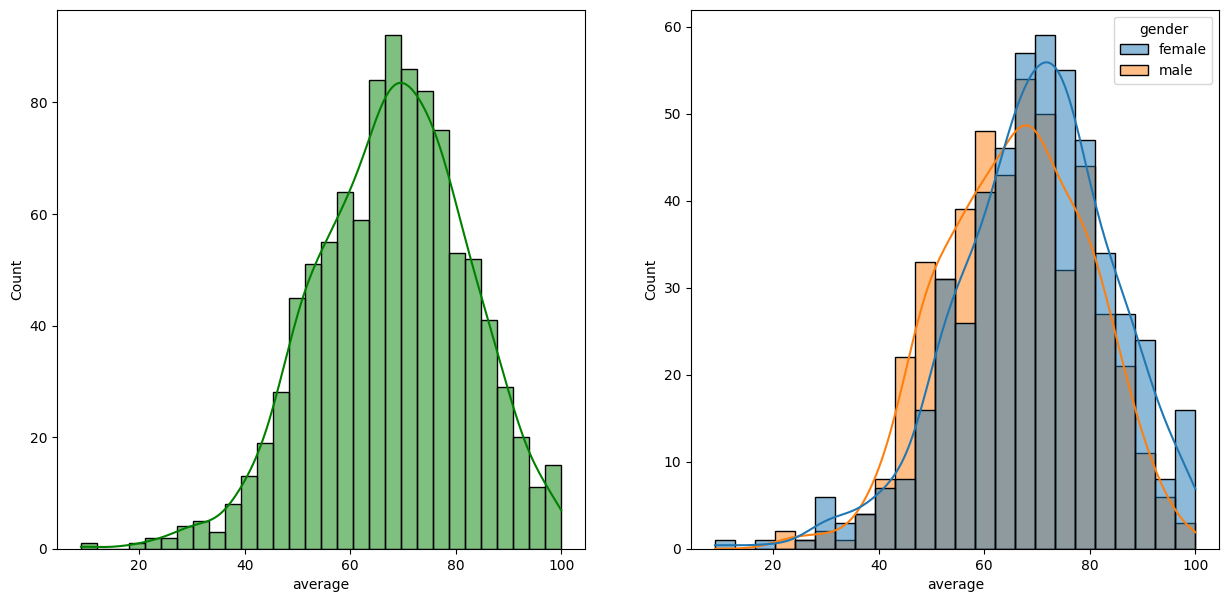

In [57]:
fig, axs = plt.subplots(1,2, figsize=(15,7))
sns.histplot(data=df, x='average', bins=30, kde=True, color='g',ax=axs[0])
sns.histplot(data=df,x='average', kde=True, hue='gender',ax=axs[1])
plt.show()

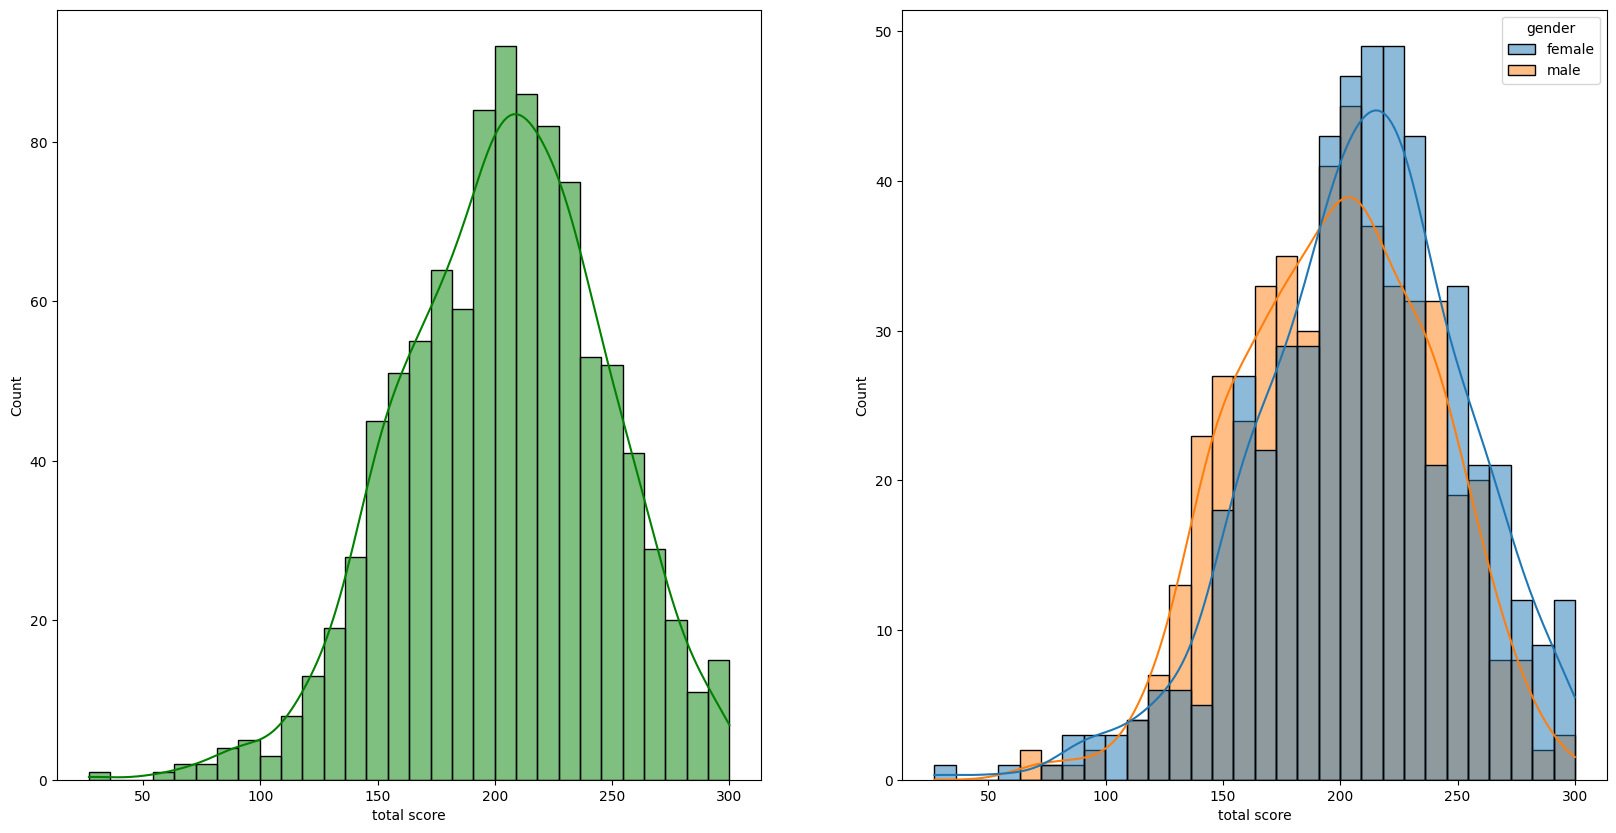

In [58]:
fig,axs =plt.subplots(1,2, figsize=(20,10))
sns.histplot(data=df,x='total score',bins=30, kde=True, color='g',ax=axs[0])
sns.histplot(data=df,x='total score',bins=30, kde=True, hue='gender',color='g',ax=axs[1])
plt.show()

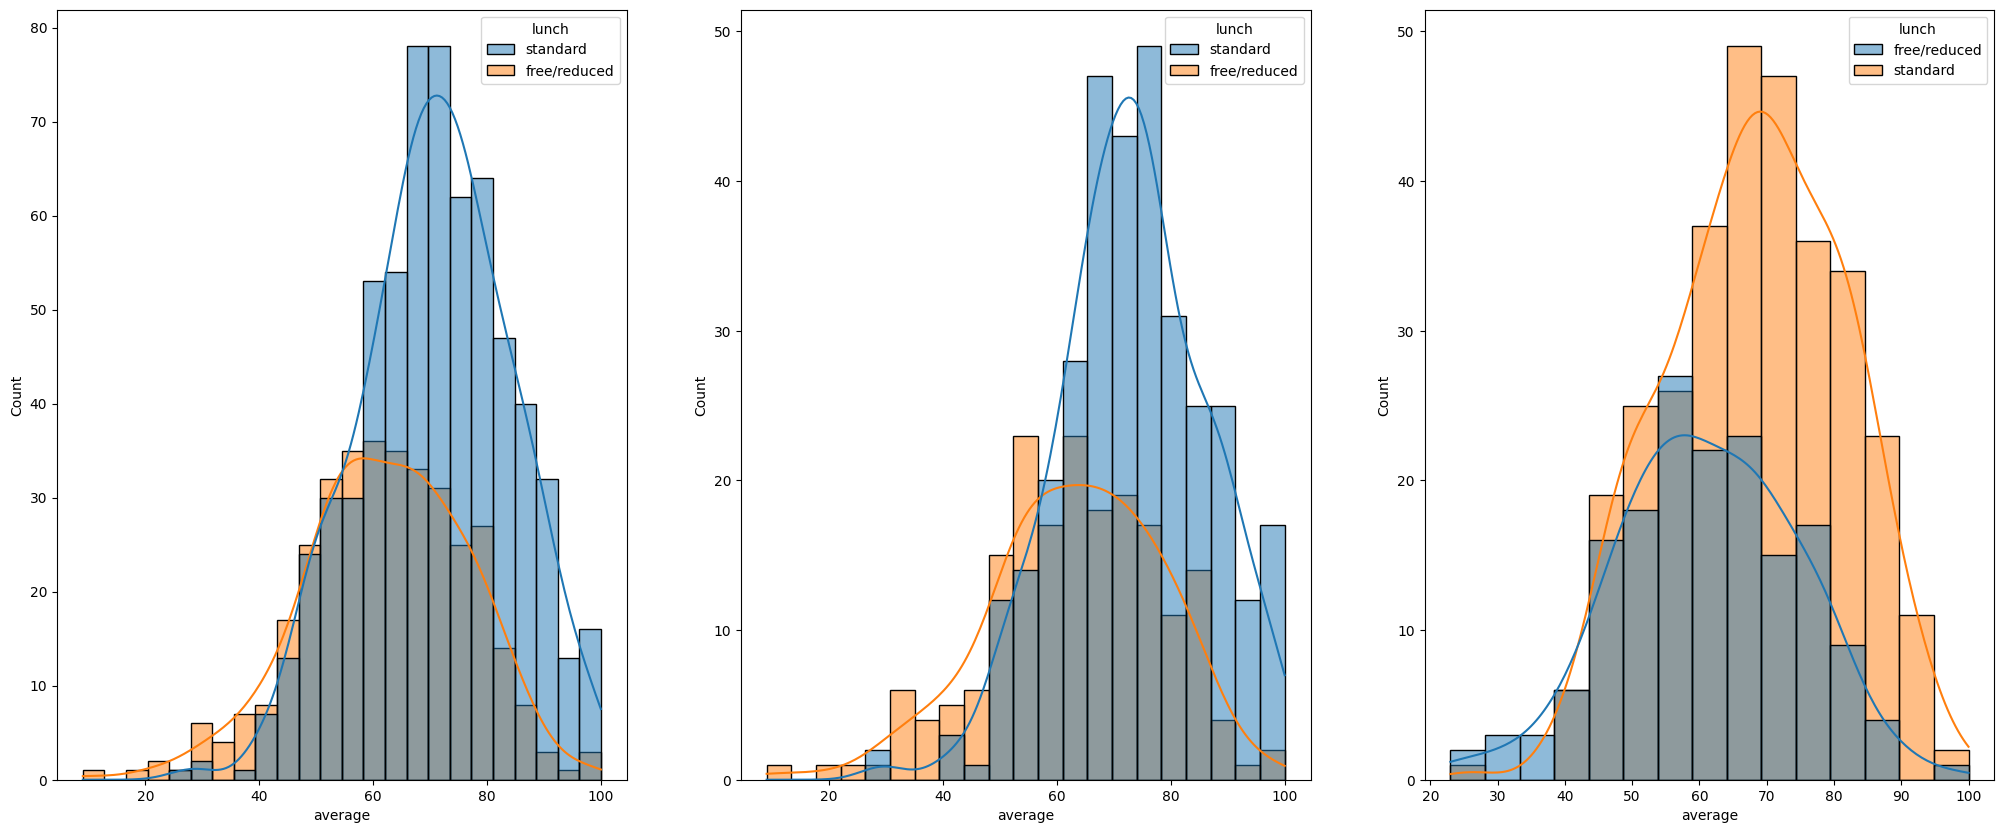

In [59]:
fig, axs = plt.subplots(1,3, figsize=(25,10))
sns.histplot(data=df,x='average',kde=True,hue='lunch',ax=axs[0])
sns.histplot(data=df[df.gender == 'female'], x='average',kde=True,hue='lunch',ax=axs[1])
sns.histplot(data=df[df.gender == 'male'], x='average',kde=True,hue='lunch',ax=axs[2])
plt.show()

`Insights`

- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

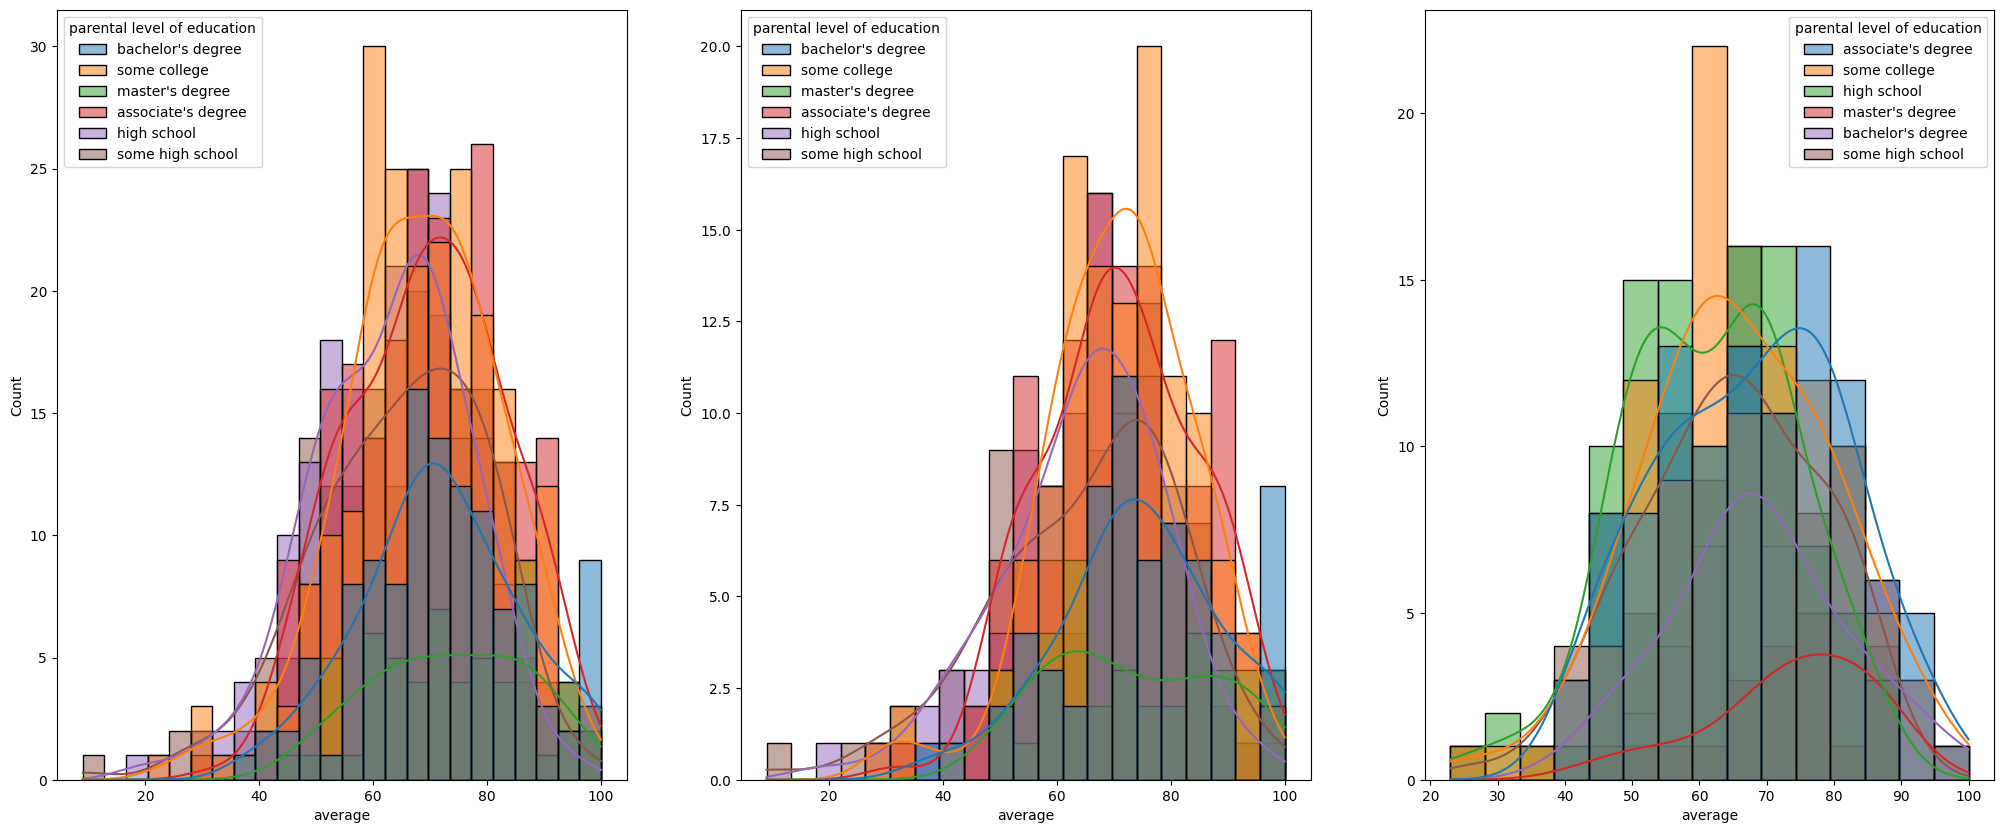

In [60]:
fig, axs = plt.subplots(1,3, figsize=(25,10))
sns.histplot(data=df,x='average',kde=True,hue='parental level of education',ax=axs[0])
sns.histplot(data=df[df.gender == 'female'], x='average',kde=True,hue='parental level of education',ax=axs[1])
sns.histplot(data=df[df.gender == 'male'], x='average',kde=True,hue='parental level of education',ax=axs[2])
plt.show()

`Insights`

- In general parent's education don't help student perform well in exam.

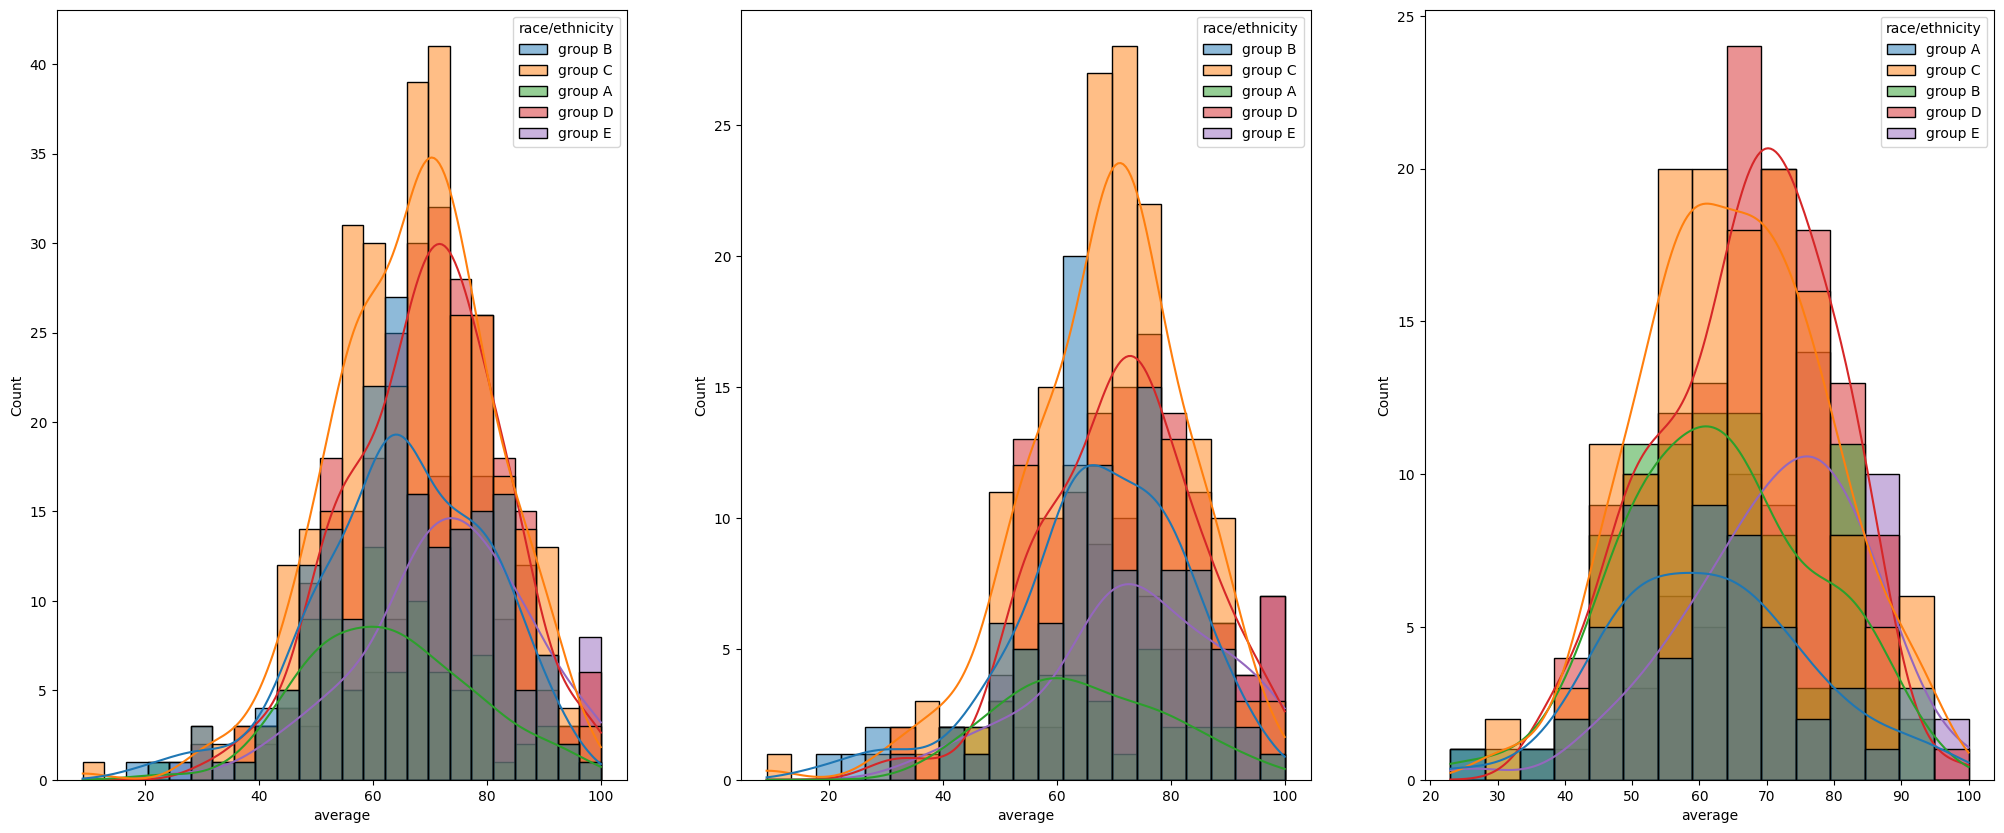

In [61]:
fig, axs = plt.subplots(1,3, figsize=(25,10))
sns.histplot(data=df,x='average',kde=True,hue='race/ethnicity',ax=axs[0])
sns.histplot(data=df[df.gender == 'female'], x='average',kde=True,hue='race/ethnicity',ax=axs[1])
sns.histplot(data=df[df.gender == 'male'], x='average',kde=True,hue='race/ethnicity',ax=axs[2])
plt.show()

`Insights`

- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

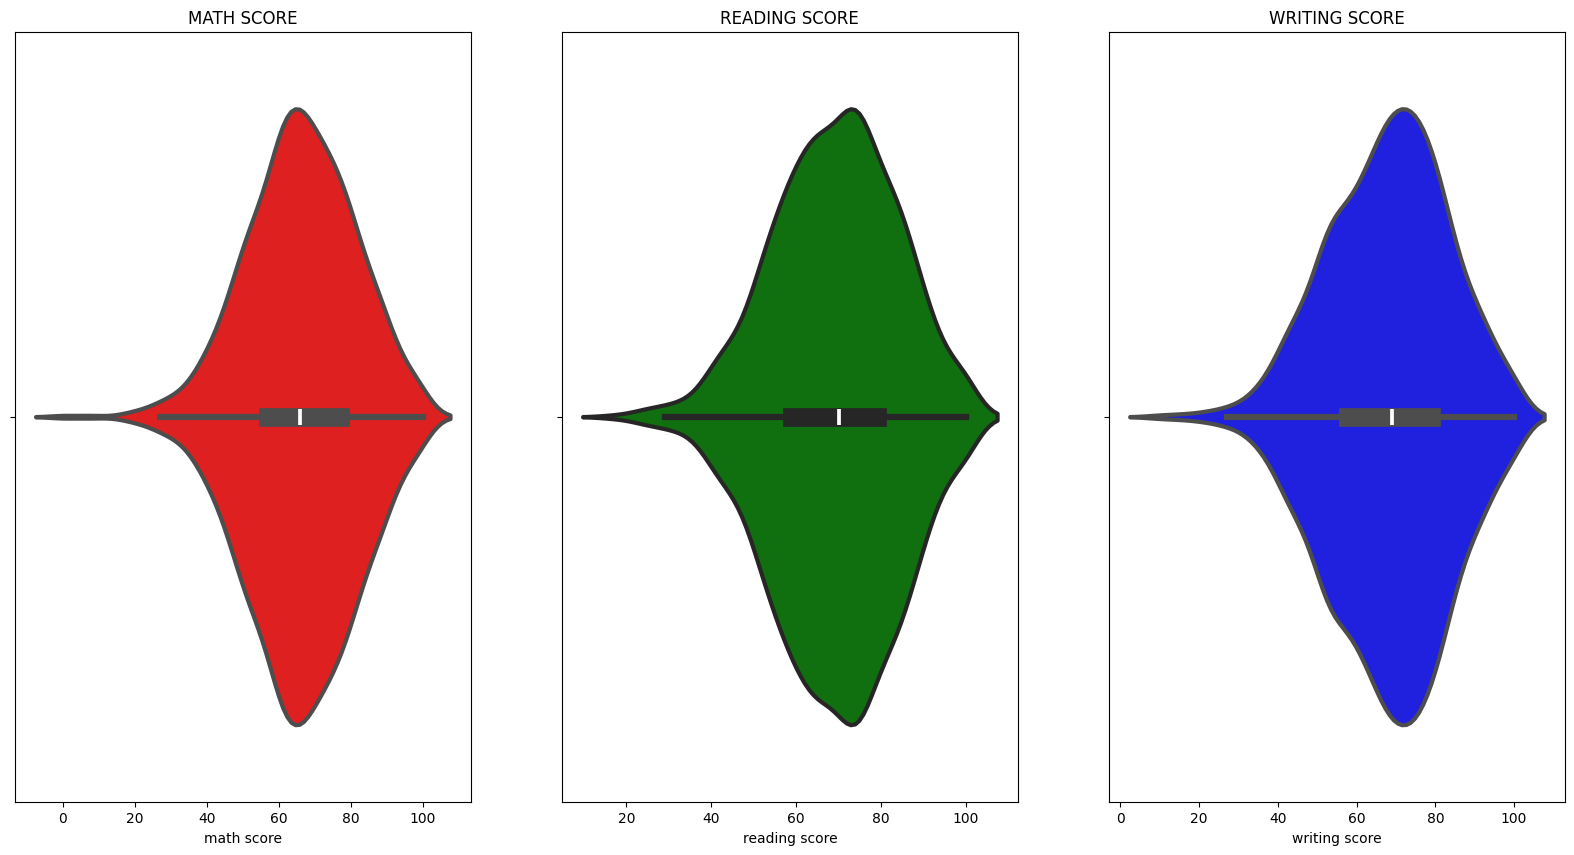

In [63]:
plt.figure(figsize=(20,10))
plt.subplot(131)
plt.title('MATH SCORE')
sns.violinplot(data=df, x='math score', color='red', linewidth=3)
plt.subplot(132)
plt.title('READING SCORE')
sns.violinplot(data=df, x='reading score', color='green', linewidth=3)
plt.subplot(133)
plt.title('WRITING SCORE')
sns.violinplot(data=df, x='writing score', color='blue', linewidth=3)
plt.show()

`Insights`

- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

In [87]:
df.columns, df['test preparation course'].value_counts(), df['parental level of education'].value_counts()

(Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
        'test preparation course', 'math score', 'reading score',
        'writing score', 'average', 'total score'],
       dtype='object'),
 test preparation course
 none         642
 completed    358
 Name: count, dtype: int64,
 parental level of education
 some college          226
 associate's degree    222
 high school           196
 some high school      179
 bachelor's degree     118
 master's degree        59
 Name: count, dtype: int64)

`Multivariate Analysis using pieplot`

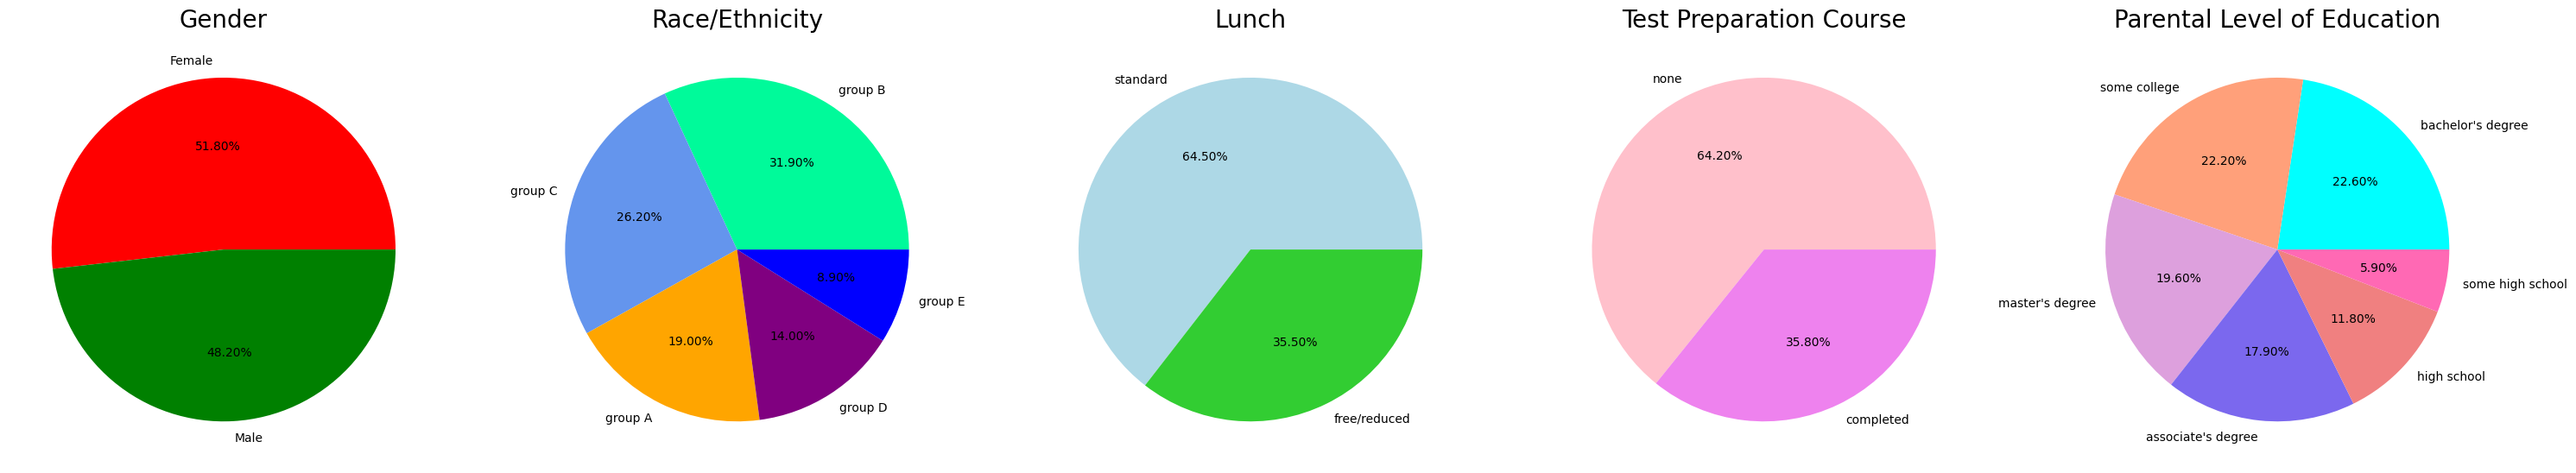

In [96]:
plt.rcParams['figure.figsize'] = (30,20) #plt.rcParams is matplotlib's global configuration 
                                          #dictionary — it controls default settings that apply 
                                          # to every plot you create afterward, unless you override 
                                          # them individually for a specific plot
                                          
_, axs = plt.subplots(1,5)

#Gender Pie
size = df['gender'].value_counts()
labels = 'Female','Male'
color = ['red','green']

axs[0].pie(size, colors=color, labels=labels, autopct='%.2f%%')
axs[0].set_title('Gender', fontsize=20)

#Race/Ethnicity Pie
axs[1].pie(df['race/ethnicity'].value_counts(),
           labels = df['race/ethnicity'].unique(),
           colors=['mediumspringgreen','cornflowerblue','orange','purple','blue'],
           autopct = '%.2f%%')
axs[1].set_title('Race/Ethnicity', fontsize=20)

#Lunch pie
axs[2].pie(df['lunch'].value_counts(),
           labels = df['lunch'].unique(),
           colors=['lightblue','limegreen'],
           autopct = '%.2f%%')
axs[2].set_title('Lunch', fontsize=20)

#Test Preparation Course
axs[3].pie(df['test preparation course'].value_counts(), 
           labels=df['test preparation course'].unique(),
           colors=['pink', 'violet'],
           autopct = '%.2f%%')
axs[3].set_title('Test Preparation Course', fontsize=20)

#Parental Level of Education Pie
axs[4].pie(df['parental level of education'].value_counts(), 
           labels=df['parental level of education'].unique(),
           colors=['cyan', 'lightsalmon', 'plum', 'mediumslateblue', 'lightcoral','hotpink' ],
           autopct = '%.2f%%')
axs[4].set_title('Parental Level of Education', fontsize=20)

plt.tight_layout()
plt.grid()
plt.show()

`Insights`

- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree" 

`Feature Wise Visualization`

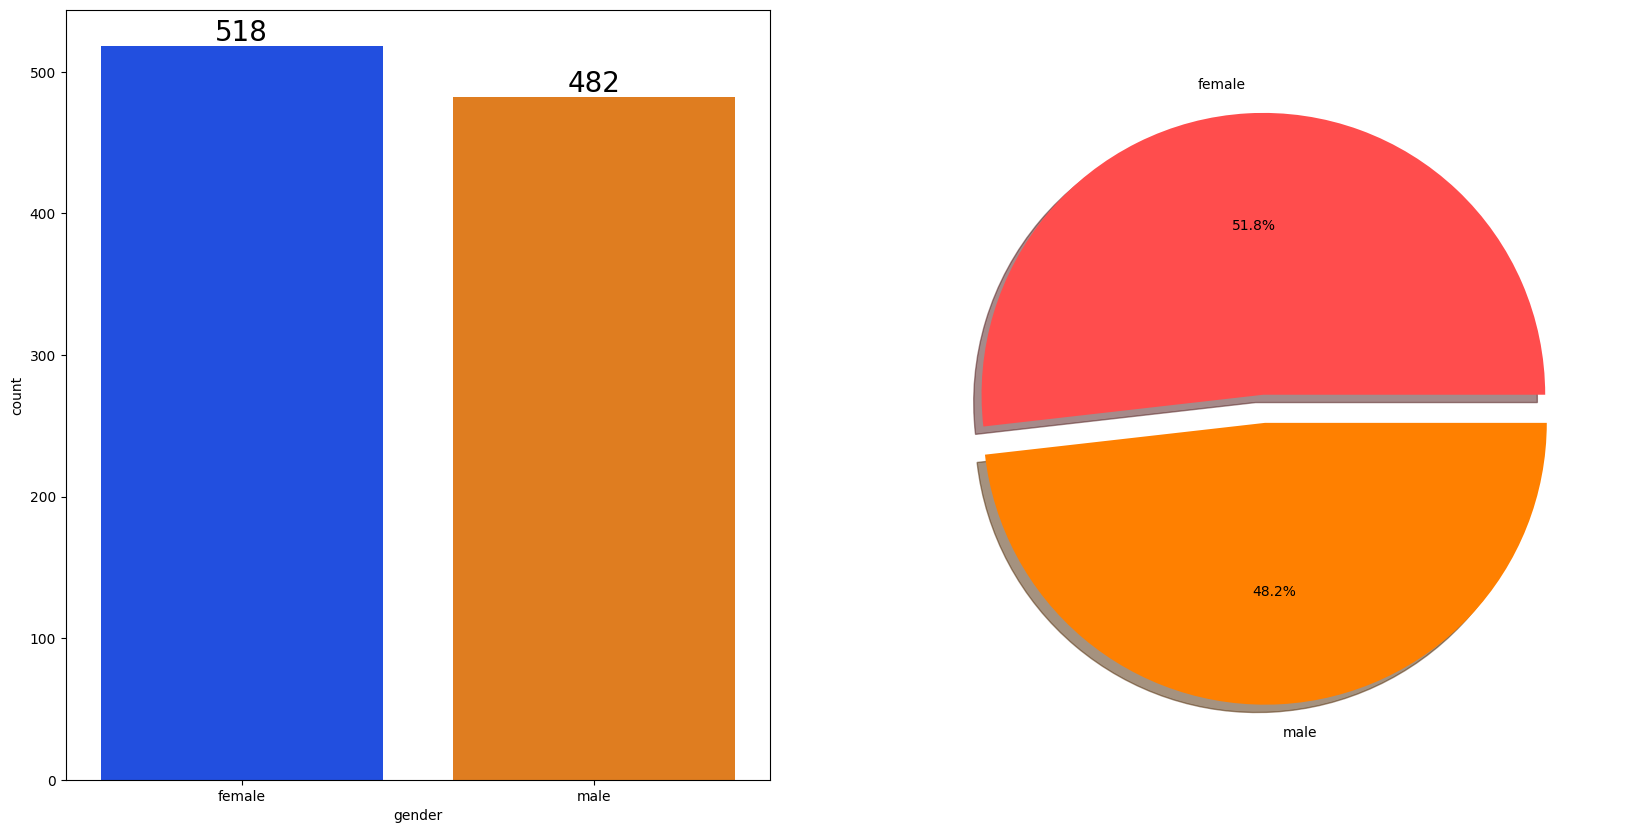

In [99]:
f,ax = plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'], data=df,palette='bright',ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
ax[1].pie(x=df['gender'].value_counts(), labels=df['gender'].unique(),explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'] )
plt.show()

In [103]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,average,total score
gender,,,,,
female,63.633205,72.608108,72.467181,69.569498,208.708494
male,68.728216,65.473029,63.311203,65.837483,197.512448


In [107]:
df.groupby('gender')['math score'].mean()

gender
female    63.633205
male      68.728216
Name: math score, dtype: float64

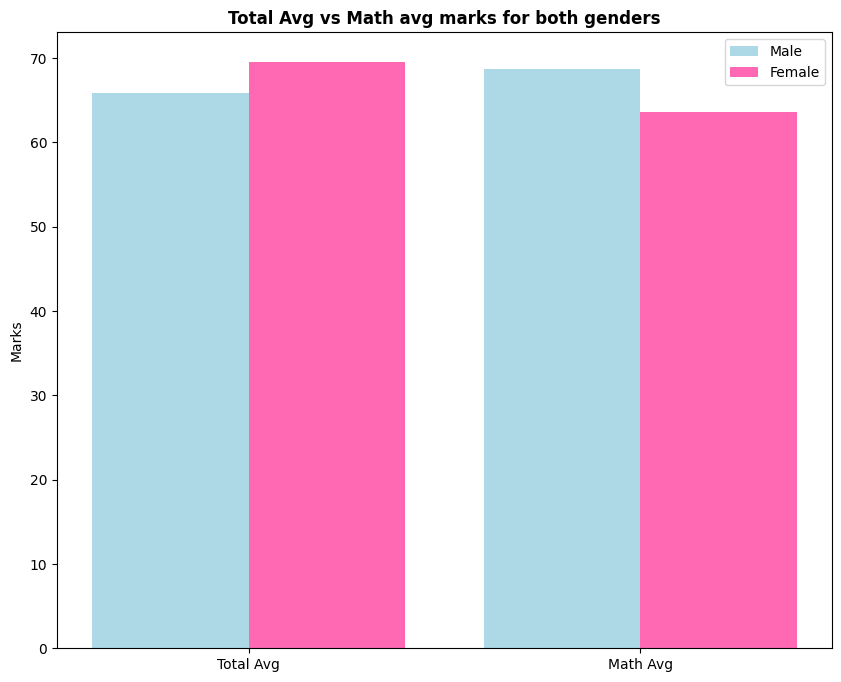

In [121]:
plt.figure(figsize=(10,8))
X = ['Total Avg', 'Math Avg']

female_scores = [gender_group['average'][0], gender_group['math score'][0]]
male_scores = [gender_group['average'][1], gender_group['math score'][1]]

X_axis = np.arange(len(X))


plt.bar(X_axis - 0.2, male_scores, 0.4, label= 'Male', color= 'lightblue')
plt.bar(X_axis + 0.2 , female_scores, 0.4, label= 'Female', color= 'hotpink')

plt.xticks(X_axis,X)
plt.ylabel('Marks')
plt.title('Total Avg vs Math avg marks for both genders', fontweight = 'bold')
plt.legend()
plt.show()

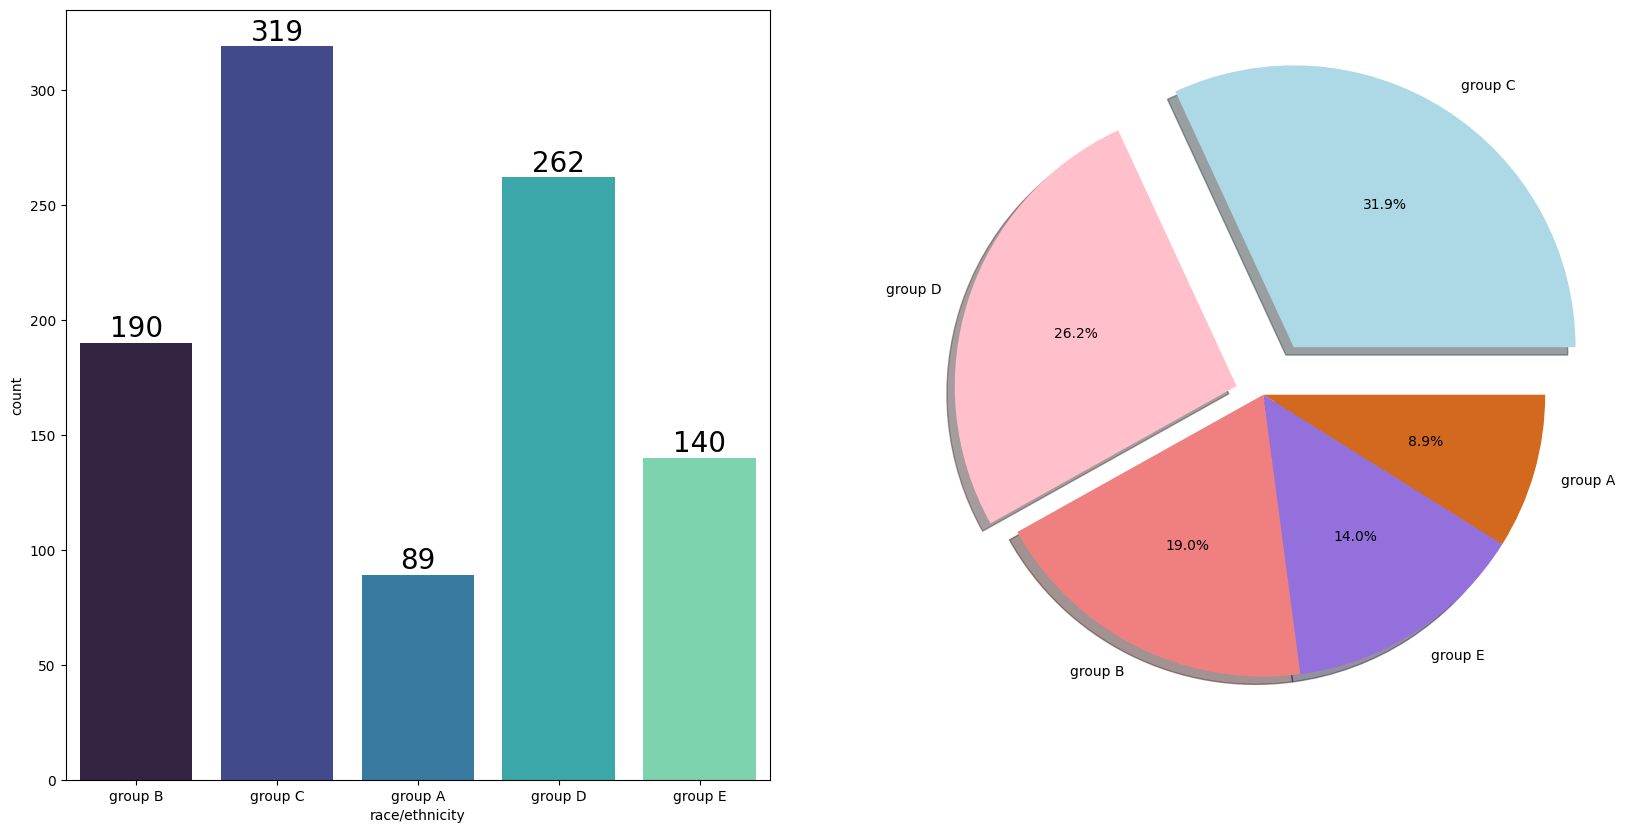

In [128]:
f,ax = plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'], data=df,palette = 'mako',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
ax[1].pie(x=df['race/ethnicity'].value_counts(),labels= df['race/ethnicity'].value_counts().index, explode=[0.2,0.1,0,0,0],autopct='%1.1f%%',shadow=True, colors=['lightblue', 'pink', 'lightcoral','mediumpurple','chocolate'])
plt.show()

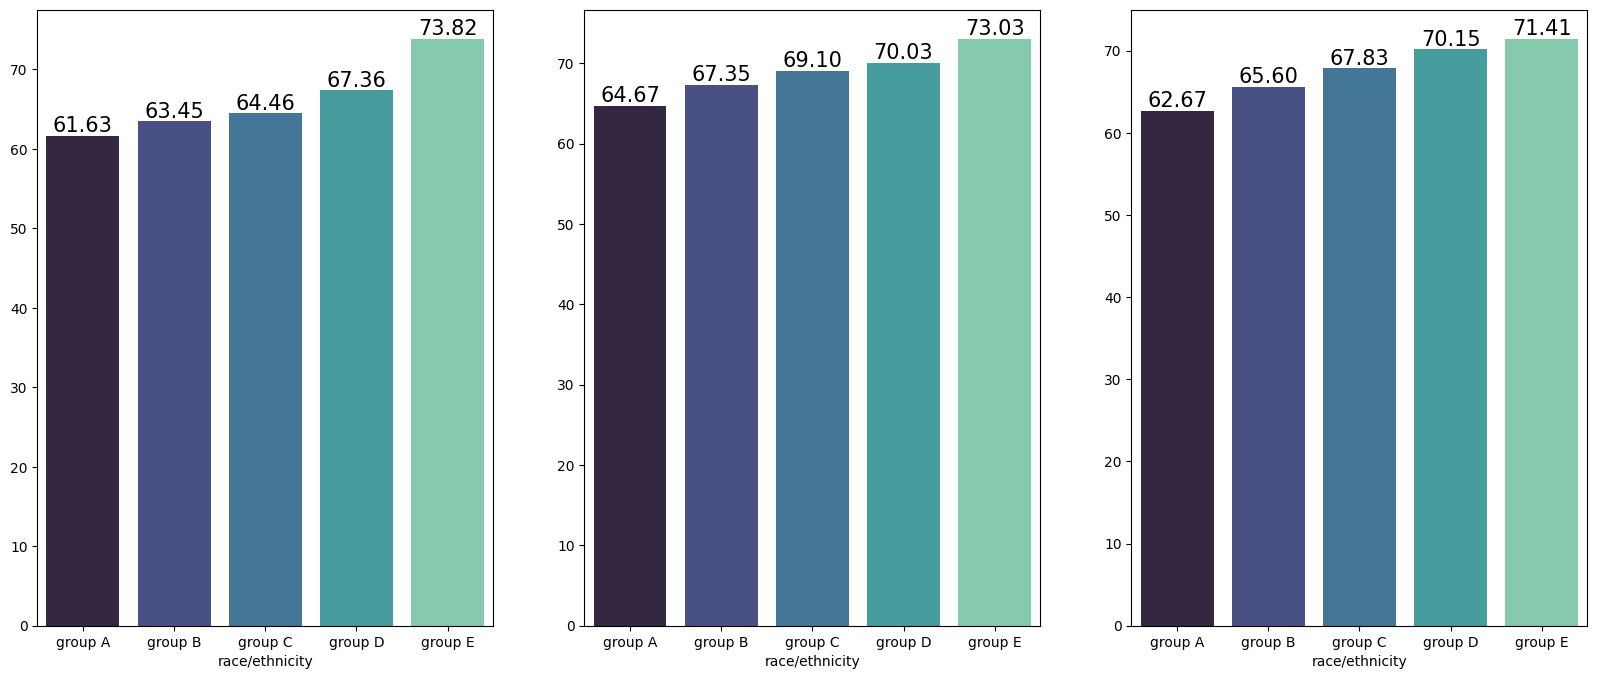

In [136]:
numeric_mean_groups = df.groupby('race/ethnicity').mean(numeric_only=True)
math_mean = numeric_mean_groups['math score']
read_mean = numeric_mean_groups['reading score']
write_mean = numeric_mean_groups['writing score']

f,ax = plt.subplots(1,3,figsize=(20,8))

sns.barplot(x=math_mean.index, y=math_mean.values, palette='mako', ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container, color='black',size=15, fmt='%.2f')
    
sns.barplot(x=read_mean.index, y=read_mean.values, palette='mako', ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, color='black',size=15,fmt='%.2f')

sns.barplot(x=write_mean.index, y=write_mean.values, palette='mako', ax=ax[2])
for container in ax[2].containers:
    ax[2].bar_label(container, color='black',size=15, fmt='%.2f')

`Insights`

- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.
- Students from a lower Socioeconomic status have a lower avg in all course subjects

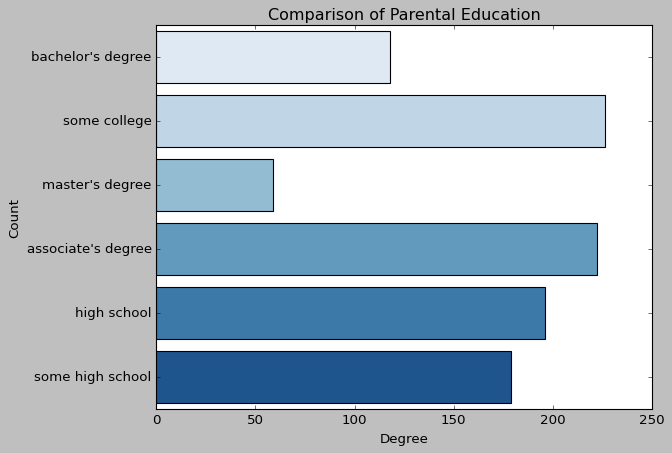

In [146]:
plt.rcParams['figure.figsize'] = (15,9)
plt.style.use('classic')
sns.countplot(df['parental level of education'], palette='Blues')
plt.title('Comparison of Parental Education')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.show()

In [142]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

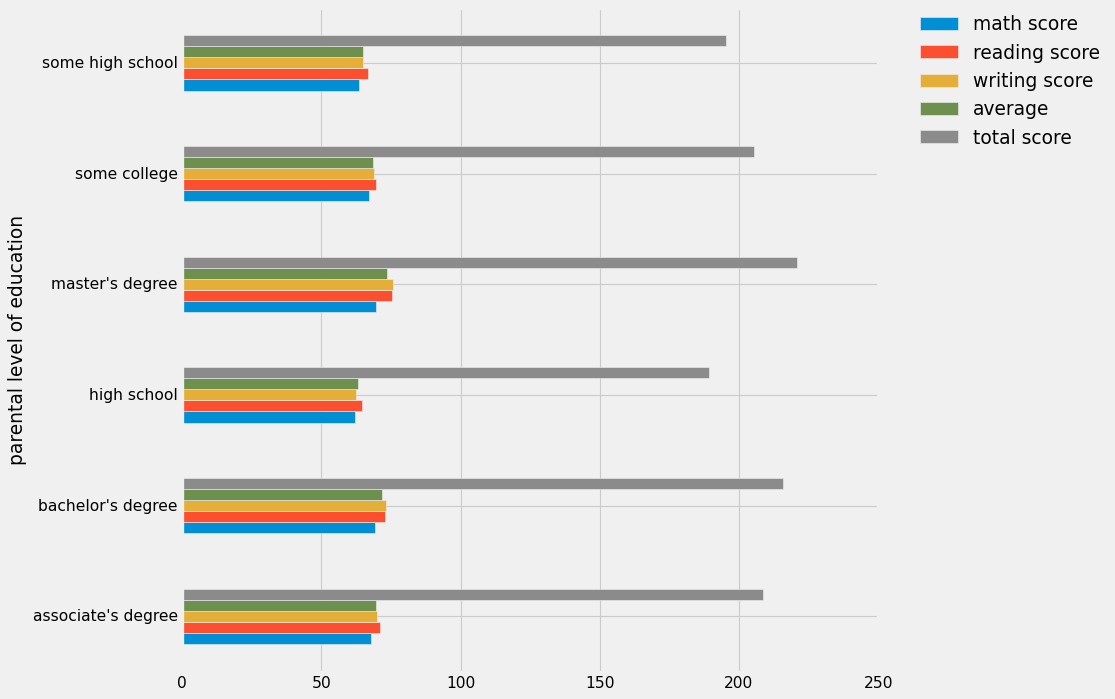

In [149]:
plt.style.use('fivethirtyeight')
df.groupby('parental level of education').mean(numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05,1), loc=2, borderaxespad=0.)
plt.show()

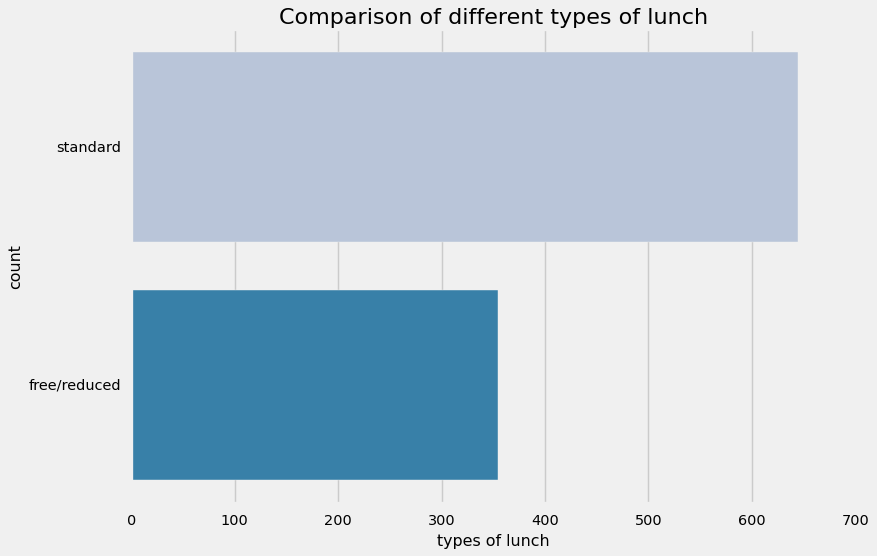

In [150]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

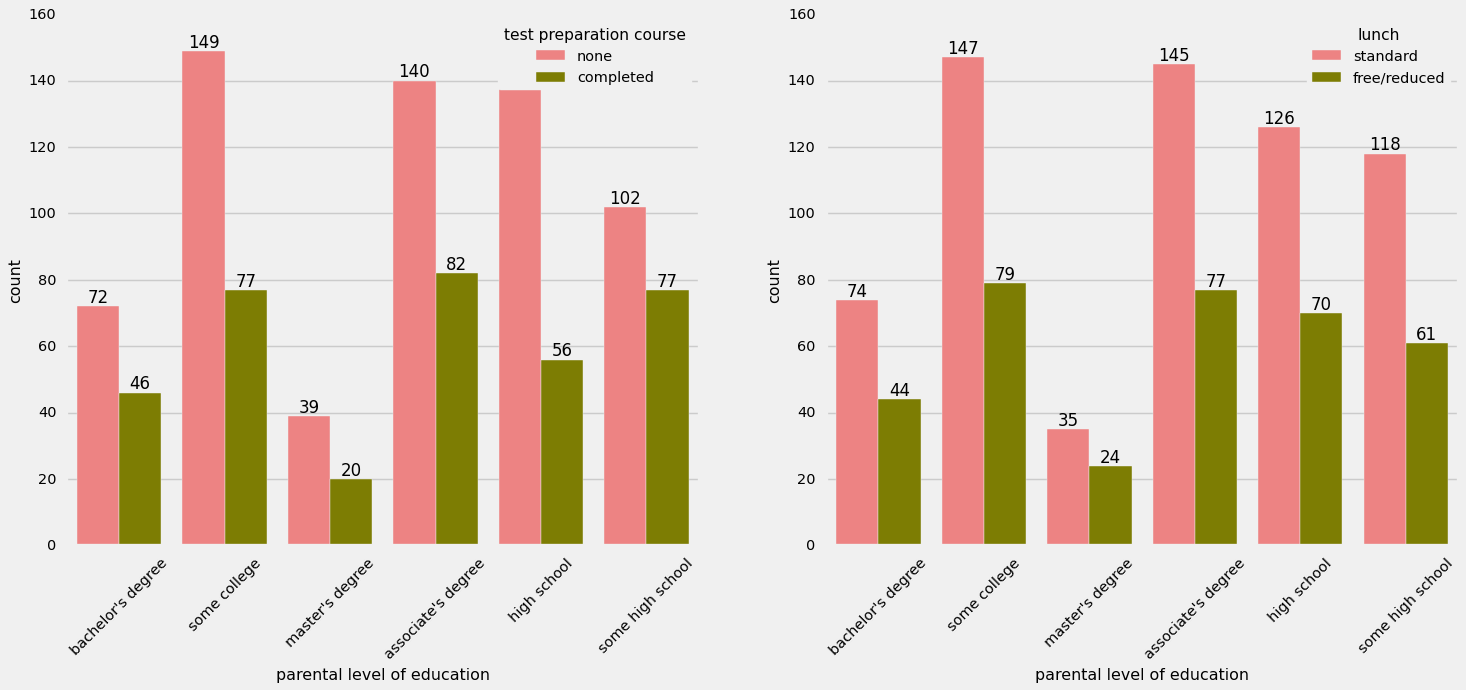

In [159]:

f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x='parental level of education', data=df, hue='test preparation course',saturation=0.95,ax=ax[0], palette=['lightcoral', 'olive'] ) 
for container in ax[0].containers:
    ax[0].bar_label(container, color='black',size=15)
ax[0].tick_params(axis='x', rotation=45)

sns.countplot(x='parental level of education', data=df, hue='lunch',saturation=0.95,ax=ax[1], palette=['lightcoral', 'olive'] ) 
for container in ax[1].containers:
    ax[1].bar_label(container, color='black',size=15)
ax[1].tick_params(axis='x', rotation=45)

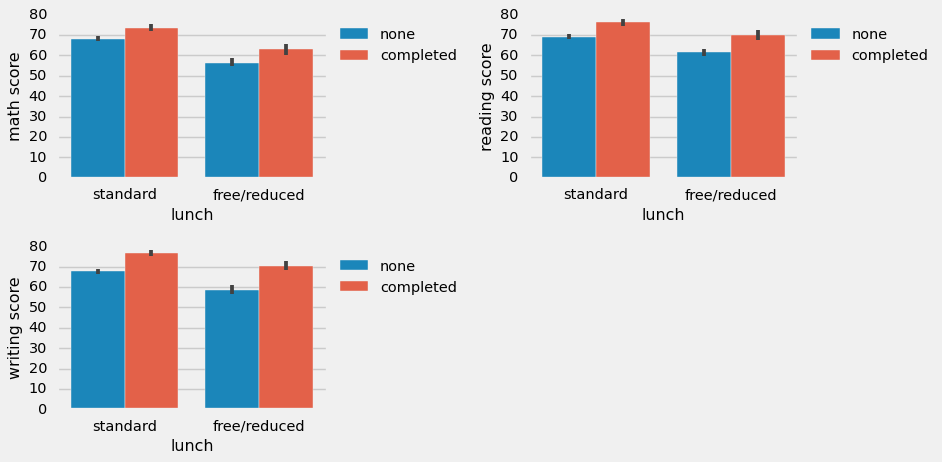

In [162]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
ax1 = sns.barplot (x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.subplot(2,2,2)
ax2 = sns.barplot (x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
ax2.legend(loc= 'upper left', bbox_to_anchor=(1,1))
plt.subplot(2,2,3)
ax3= sns.barplot (x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])
ax3.legend(loc= 'upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

`Checking the outliers`

In [165]:
help(plt.boxplot)

Help on function boxplot in module matplotlib.pyplot:

boxplot(x, notch=None, sym=None, vert=None, whis=None, positions=None, widths=None, patch_artist=None, bootstrap=None, usermedians=None, conf_intervals=None, meanline=None, showmeans=None, showcaps=None, showbox=None, showfliers=None, boxprops=None, labels=None, flierprops=None, medianprops=None, meanprops=None, capprops=None, whiskerprops=None, manage_ticks=True, autorange=False, zorder=None, capwidths=None, *, data=None)
    Draw a box and whisker plot.
    
    The box extends from the first quartile (Q1) to the third
    quartile (Q3) of the data, with a line at the median.  The
    whiskers extend from the box by 1.5x the inter-quartile range
    (IQR).  Flier points are those past the end of the whiskers.
    See https://en.wikipedia.org/wiki/Box_plot for reference.
    
    .. code-block:: none
    
              Q1-1.5IQR   Q1   median  Q3   Q3+1.5IQR
                           |-----:-----|
           o      |--------|    

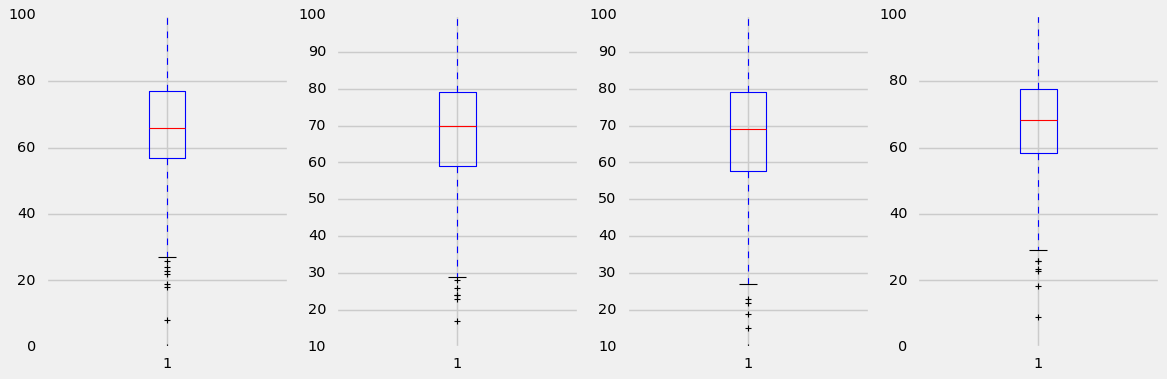

In [166]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
plt.boxplot(df['math score'])
plt.subplot(142)
plt.boxplot(df['reading score'])
plt.subplot(143)
plt.boxplot(df['writing score'])
plt.subplot(144)
plt.boxplot(df['average'])
plt.show()

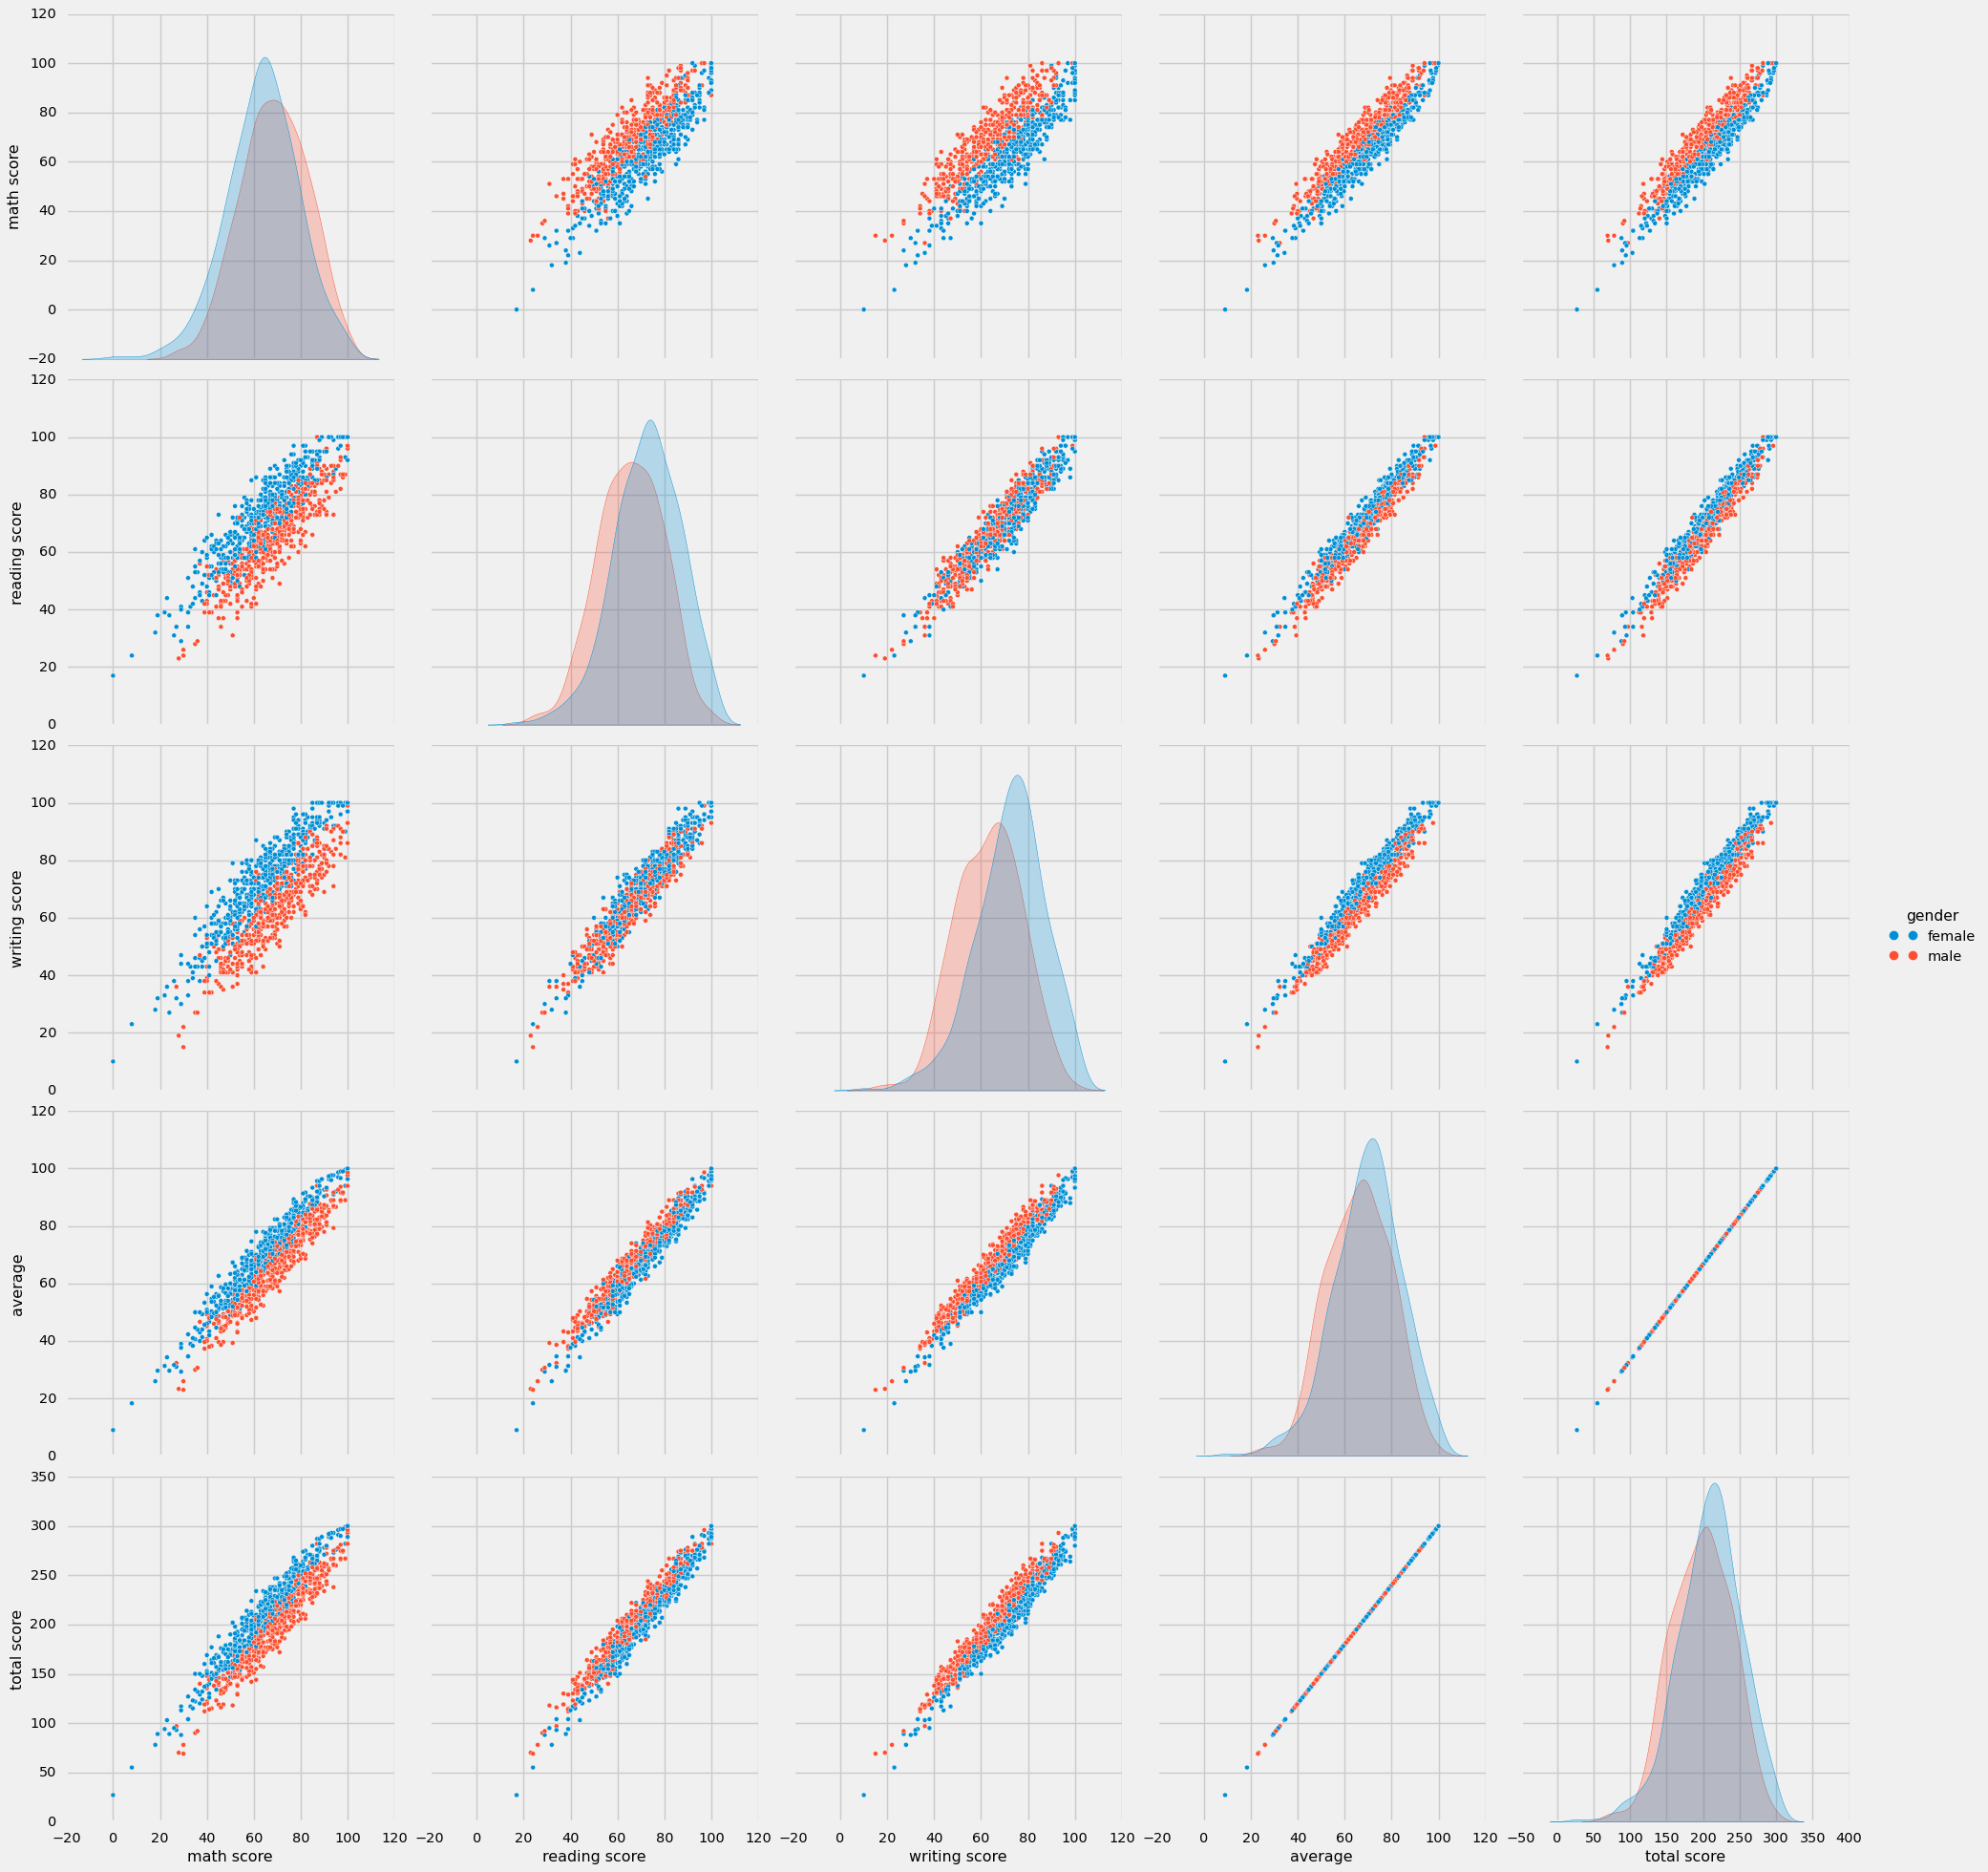

In [169]:
sns.pairplot(df,hue='gender',height=5)
plt.show()

sns.pairplot() creates a grid of scatter plots, comparing every numeric column against every other numeric column in your DataFrame